In [47]:
# Import custom mahjong classes
from helper import config
from helper.tile_util import Tile, MahjongMeld
from helper.utility import Hand136, MSPZD, MahjongConverter
from helper.game_util import GameLogEntry, GamePhase
from helper.player import MahjongPlayer
from helper.game import MahjongGame
from helper.visualizer import MahjongReplay, VizMode

from typing import List, Dict, Set, Tuple, Union

from mahjong.hand_calculating.hand import HandCalculator
from mahjong.hand_calculating.hand_config import HandConfig
from mahjong.shanten import Shanten
from mahjong.tile import TilesConverter
from mahjong.agari import Agari

from dataclasses import dataclass
import heapq

from time import time
import random
import matplotlib.pyplot as plt
import numpy as np
import copy
import math

In [48]:
def setup_player(name: str, used_tiles: List[int] = None) -> Tuple[MahjongPlayer, List[int], List[int], int, List[int]]:
    """
    Setup a single instance of MahjongPlayer for one kyoku.
    Returns: player, wall (list of 136 ids), dead_wall (list of 136 ids), draw_tile (136 id), dora_indicators (list of 136 ids)
    `used_tiles` (optional): list of tile136 ids to exclude from the pool (e.g., already visible tiles).
    """
    player = MahjongPlayer(0, name)
    player.reset_for_kyoku(seat_wind=0, is_dealer=True)

    used_tiles = set(used_tiles or [])

    # build full tile pool excluding used_tiles
    all_tiles = [t for t in range(136) if t not in used_tiles]

    if len(all_tiles) < MahjongGame.DEAD_WALL_SIZE + 14:  # need at least dead wall + 14 tiles for hand+draw+dora
        raise ValueError("Not enough tiles available after excluding used_tiles")

    random.shuffle(all_tiles)

    # Reserve dead wall (last 14 tiles)
    dead_wall = all_tiles[-MahjongGame.DEAD_WALL_SIZE:]
    wall = all_tiles[:-MahjongGame.DEAD_WALL_SIZE]

    # give out hand (13 tiles)
    hand_tiles = [wall.pop() for _ in range(13)]
    player.set_hand(hand_tiles)

    # draw tile and dora indicator
    draw_tile = wall.pop()
    dora_indicators = [wall.pop()]

    return player, wall, dead_wall, draw_tile, dora_indicators


# Simulating the simulation
- Simulate individual sections / algorithms for solving the rii-chi mahjong game theory
- Below code cell is for checking functionalities
  - Main functionality in mahjong library are...
    - `HandCalculator.estimate_hand_value(**, HandConfig())`
    - `Shanten.calculate_shanten(**, use_chiitoitsu, use_kokushi)`

In [49]:
player, wall, dead_wall, draw_tile, dora_indicators = setup_player("Greedy")
hand_136 = player.hand
draw_136 = Hand136(draw_tile)
hand_34 = hand_136.to_34()
draw_34 = draw_136.to_34()
hand_mspzd = hand_136.to_mspzd(True)
draw_mspzd = draw_136.to_mspzd(True)
# combined len==14
comb_hand_136 = hand_136+draw_136
comb_hand_34 = comb_hand_136.to_34()
comb_hand_mspzd = comb_hand_136.to_mspzd()

print("Current Hand: ", hand_136.ids, "->", hand_mspzd)
print(f"Drawn tile: {draw_136.ids} -> {draw_mspzd}")

hand_calculator = HandCalculator()
config = HandConfig()

result = hand_calculator.estimate_hand_value(
    tiles = comb_hand_136,
    win_tile = draw_tile,
    melds = player._to_library_meld_tuples(),
    dora_indicators = dora_indicators,
    config = config
)
print(f"HandCalculator.estimate_hand_value() = {result}")

# Get Shanten of current hand
shanten = Shanten()
num_shanten = shanten.calculate_shanten( # Calculate minimum shanten[int]
    tiles_34 = comb_hand_34,
    use_chiitoitsu = False,
    use_kokushi = False
)
print(f"Current shanten: Shanten.calculate_shanten() = {num_shanten}")

Current Hand:  [19, 20, 40, 44, 48, 53, 72, 87, 100, 110, 111, 119, 121] -> 56m2345p148sEEWNz
Drawn tile: [42] -> 2p
HandCalculator.estimate_hand_value() = hand_not_winning
Current shanten: Shanten.calculate_shanten() = 3


# Greedy Algo
1. Given depth $d$, a hand in 136 format of `len=14`
2. Replace each tile in hand with existing tile from wall
3. Recurse
4. $E = p*\mathbb{shanten}$ Where $E$ is Expected value, $p$ is the probability of pulling that tile

### Search Space Math
**Search Space**

Given $T = 34$, 4 tiles per $T$, depth $d$

Then search space (leaf count) is roughly $N(d) = {476}^d$

**Uke ires**

Given $S(H)$ is $shanten$ for a hand $H$, then for each tile type $t \in T$

Ukeire is if $S(H) < S(H+t)$




### Time
Around 2.5s / 100 Branches. *NOT REALISTIC*

In [50]:
# Greedy N-depth search on which hand is best for Shanten

class SearchStep:
    def __init__(self, depth, discard=None, draw=None, prob=1.0, shanten=None, ukeire=None):
        self.depth = depth
        self.discard = discard
        self.draw = draw
        self.prob = prob
        self.shanten = shanten
        self.ukeire = ukeire

    def _to_mspzd(self, n):
        return Hand136(n).to_mspzd()

    def __repr__(self):
        return f"\n[D:{self.depth}, discard:{self._to_mspzd(self.discard)}, draw:{self._to_mspzd(self.draw)}, shanten:{self.shanten}, ukeire:{self.ukeire}, P:{self.prob:.4f}]"


class SearchResult:
    def __init__(self, score, path):
        self.score = score        # expected shanten score
        self.path = path          # list[SearchStep]

    def __repr__(self):
        return f"Score:{self.score}, path:{self.path}"


class GreedyShantenSearch:

    UKEIRE_COEFF = 0.01

    def __init__(self):
        self.shanten = Shanten()
        self.NUM_BRANCHES = 0

    def _get_shanten(self, hand_136: Hand136) -> int:
        """Hand must contain 14 tiles"""
        return self.shanten.calculate_shanten(hand_136.to_34())

    def _analyze_draws(self, hand_136: Hand136, wall_counts: List[int]):
        """
        For a 13-tile hand simulate all possible draws.
        Returns list of (tile_type, remaining, new_shanten)
        """
        results = []

        for tile_type in range(34):

            remaining = wall_counts[tile_type]
            if remaining == 0:
                continue

            draw_tile = tile_type * 4

            new_hand = copy.copy(hand_136)
            new_hand = new_hand.add(draw_tile)

            new_shanten = self._get_shanten(new_hand)

            results.append((tile_type, remaining, new_shanten))

        return results

    def _get_ukeire(self, hand_136: Hand136, wall_counts: List[int]) -> int:
        """
        hand_136 must contain 13 tiles
        """
        current_shanten = self.shanten.calculate_shanten(hand_136.to_34())

        ukeire = 0
        draws = self._analyze_draws(hand_136, wall_counts)

        for _, remaining, new_shanten in draws:
            if new_shanten < current_shanten:
                ukeire += remaining

        return ukeire

    def _evaluate(self, hand_136: Hand136, wall_counts: List[int]) -> float:
        """
        Evaluate a 14-tile hand
        """
        self.NUM_BRANCHES += 1
        if self.NUM_BRANCHES % 100 == 0:
            print(f"Current Branch: {self.NUM_BRANCHES}")

        shanten = self._get_shanten(hand_136)

        # convert to 13 tile state for ukeire calculation
        best_ukeire = 0

        for discard in list(hand_136):
            hand13 = copy.copy(hand_136)
            hand13 = hand13.remove(discard)

            ukeire = self._get_ukeire(hand13, wall_counts)
            best_ukeire = max(best_ukeire, ukeire)

        return shanten - GreedyShantenSearch.UKEIRE_COEFF * best_ukeire

    def search(
        self,
        hand_136: Hand136,
        wall_counts: List[int],
        depth: int,
        prob: float = 1.0,
        path=None
    ) -> Union[SearchResult, None]:

        if path is None:
            path = []

        # BASE CASE
        if depth == 0:
            return SearchResult(
                score=self._evaluate(hand_136, wall_counts),
                path=path
            )

        best_result = None
        best_score = -math.inf

        current_shanten = self._get_shanten(hand_136)

        for discard in list(hand_136):

            # ---- DISCARD ----
            hand_after_discard = copy.copy(hand_136)
            hand_after_discard = hand_after_discard.remove(discard)  # 13 tiles

            ukeire = self._get_ukeire(hand_after_discard, wall_counts)

            discard_step = SearchStep(
                depth=depth,
                discard=discard,
                prob=prob,
                ukeire=ukeire
            )

            total_tiles = sum(wall_counts)

            expected_score = 0
            best_child_result = None

            # ---- DRAW ANALYSIS ----
            draws = self._analyze_draws(hand_after_discard, wall_counts)

            for tile_type, remaining, new_shanten in draws:
                # Prune branches which worsens shanten
                if new_shanten < current_shanten:
                    continue

                draw_prob = remaining / total_tiles
                draw_tile = tile_type * 4

                new_hand = copy.copy(hand_after_discard)
                new_hand = new_hand.add(draw_tile)

                new_wall = wall_counts.copy()
                new_wall[tile_type] -= 1

                draw_step = SearchStep(
                    depth=depth,
                    draw=draw_tile,
                    prob=prob * draw_prob,
                    shanten=new_shanten
                )

                result = self.search(
                    new_hand,
                    new_wall,
                    depth - 1,
                    prob * draw_prob,
                    path + [discard_step, draw_step]
                )

                expected_score += draw_prob * -result.score

                if best_child_result is None or result.score > best_child_result.score:
                    best_child_result = result

            if expected_score > best_score:
                best_score = expected_score
                best_result = SearchResult(
                    score=expected_score,
                    path=best_child_result.path
                )

        return best_result
    
player, wall, dead_wall, draw_tile, dora_indicators = setup_player("Greedy")
shanten_calculator = Shanten()
greedy_searcher = GreedyShantenSearch()
comb_hand = player.hand.add(draw_tile)
depth = 1
# best_result = greedy_searcher.search(comb_hand, wall.copy(), depth)

# print(f"Current hand:{player.hand.to_mspzd()}, Drawn tile:{Hand136(draw_tile).to_mspzd()}")
# print(f"Combined len==14 Hand:{comb_hand.to_mspzd()}, Shanten:{shanten_calculator.calculate_shanten(comb_hand.to_34())}")
# print(f"Greedy search results:{best_result.path}")
# print(f"Results:{best_result.score}, Depth:{depth}, Num Search Branch:{greedy_searcher.NUM_BRANCHES}")

## Beam Search
- Given $B$ as beam width, $D$ as search depth, $A$ as avg number of actions (Branching factor)
- then $O(B\times A\times D)$ for speed, $O(B)$ for memory
- For Mahjong w/o pruning, $A = 34\times 14 = 476$

## Shape Efficiency
- Shanten improvement > Ukeire is not good enough. Consider _Shapes_ which are good in this order.
  - to avoid double counting, count only the longest / strongest shape
Solution, Heuristics (e.g. scoring for shapes) in order of good
- 3men e.g. 34567p waiting for 258p
- double ryanmen e.g. 3344s waiting for 25s x2
- pair in a meld e.g. 2334
- 4tile straight e.g. 2345
- pair of honor tiles with yaku e.g. EE, SS, ChunChun where E is prevalent wind and S is self wind
- ryanmen e.g. 45s waiting for 36s
- pair e.g. 22s
- complete melds e.g. 333s
- complete incrementive melds e.g. 234s
- pair and ryamen e.g. 334, NN (not yaku wind)
- middle kanchan e.g. 68m waiting for 7m
- penchan e.g. 89p waiting for 7p
- pen kanchan e.g. 13m waiting for 2m
**BAD SHAPES**
- isolated 1,9
- isolated yakuhai
  - dragons, prevalent wind, self wind is better
- isolated middle tiles 3-7
- tiles not connected to neighbours e.g. 12589m -> 5m is floating

In [51]:
from dataclasses import dataclass
from typing import List, Tuple, Dict
import heapq

@dataclass
class BeamNode:
    hand34: Tuple[int, ...]        # 34-count tuple for 13-tile hand
    wall_key: Tuple[int, ...]      # 34-count tuple for remaining wall
    score: float
    path: list

class MahjongBeamSearch:
    VALUE_COEFF = 1.0
    UKEIRE_COEFF = 0.05
    SHAPE_COEFF = 0.02
    DISCARD_YAKUHAI_PENALTY = 30.0

    def __init__(self, beam_width:int, depth:int, self_wind:int, prevalent_wind:int):
        self.beam_width = beam_width
        self.max_depth = depth
        self.self_wind = self_wind
        self.prevalent_wind = prevalent_wind

        self.shanten = Shanten()

        # caches
        self._shanten_cache: Dict[Tuple[int,...], int] = {}
        self._shape_cache: Dict[Tuple[int,...], float] = {}
        self._value_cache: Dict[Tuple[int,...], float] = {}
        self._eval_cache: Dict[Tuple[Tuple[int,...], Tuple[int,...]], float] = {}

        self.nodes_expanded = 0
        self._counter = 0

    # -----------------------------
    # small helpers (34-array ops)
    # -----------------------------
    @staticmethod
    def hand34_add_tile(hand34: Tuple[int,...], tile34: int) -> Tuple[int,...]:
        lst = list(hand34)
        lst[tile34] += 1
        return tuple(lst)

    @staticmethod
    def hand34_remove_tile(hand34: Tuple[int,...], tile34: int) -> Tuple[int,...]:
        lst = list(hand34)
        lst[tile34] -= 1
        return tuple(lst)

    @staticmethod
    def is_honor(tile34:int) -> bool:
        return 27 <= tile34 <= 33

    def is_yakuhai_tile34(self, tile34:int) -> bool:
        if tile34 in (31,32,33):  # dragons
            return True
        if tile34 == self.self_wind or tile34 == self.prevalent_wind:
            return True
        return False

    # -----------------------------
    # Cached shanten (34-array)
    # -----------------------------
    def get_shanten_from34(self, hand34: Tuple[int,...]) -> int:
        cached = self._shanten_cache.get(hand34)
        if cached is not None:
            return cached
        s = self.shanten.calculate_shanten(list(hand34))
        self._shanten_cache[hand34] = s
        return s

    # -----------------------------
    # Shape scoring (works on 34-array)
    # -----------------------------
    def shape_score_from34(self, hand34: Tuple[int,...]) -> float:
        cached = self._shape_cache.get(hand34)
        if cached is not None:
            return cached

        score = 0
        hand = list(hand34)

        for suit_start in (0,9,18):
            temp = hand[suit_start:suit_start+9].copy()

            # triplets
            for i in range(9):
                while temp[i] >= 3:
                    score += 5
                    temp[i] -= 3

            # sequences
            for i in range(7):
                while temp[i] >= 1 and temp[i+1] >= 1 and temp[i+2] >= 1:
                    score += 5
                    temp[i] -= 1
                    temp[i+1] -= 1
                    temp[i+2] -= 1

            # ryanmen (1..6)
            for i in range(1,7):
                while temp[i] >= 1 and temp[i+1] >= 1:
                    score += 7
                    temp[i] -= 1
                    temp[i+1] -= 1

            # kanchan
            for i in range(7):
                while temp[i] >= 1 and temp[i+2] >= 1:
                    score += 4
                    temp[i] -= 1
                    temp[i+2] -= 1

            # penchan edges
            if temp[0] >= 1 and temp[1] >= 1:
                score += 2
                temp[0] -= 1
                temp[1] -= 1
            if temp[7] >= 1 and temp[8] >= 1:
                score += 2
                temp[7] -= 1
                temp[8] -= 1

            # pairs
            for i in range(9):
                if temp[i] >= 2:
                    score += 6
                    temp[i] -= 2

            # isolated singles
            for i in range(9):
                if temp[i] == 1:
                    left2  = temp[i-2] if i >= 2 else 0
                    left1  = temp[i-1] if i >= 1 else 0
                    right1 = temp[i+1] if i <= 7 else 0
                    right2 = temp[i+2] if i <= 6 else 0
                    if left2 == left1 == right1 == right2 == 0:
                        score -= 5
                    temp[i] -= 1

        # honors
        for i in range(27,34):
            if hand[i] >= 3:
                score += 10
            elif hand[i] >= 2:
                score += 8

        self._shape_cache[hand34] = score
        return score

    # -----------------------------
    # Value / yakuhai scoring (34-array)
    # -----------------------------
    def value_score_from34(self, hand34: Tuple[int,...]) -> float:
        cached = self._value_cache.get(hand34)
        if cached is not None:
            return cached
        v = 0
        counts = hand34
        # dragons
        for d in (31,32,33):
            if counts[d] >= 3:
                v += 40
            elif counts[d] >= 2:
                v += 25
        # seat/prevalent winds
        for w in (self.self_wind, self.prevalent_wind):
            if w is None:
                continue
            if counts[w] >= 3:
                v += 36
            elif counts[w] >= 2:
                v += 20
        self._value_cache[hand34] = v
        return v

    # -----------------------------
    # Fast ukeire (honor-aware, normalized)
    # -----------------------------
    def get_fast_ukeire_from34(self, hand34: Tuple[int,...], wall_counts: Tuple[int,...]) -> float:
        base_shape = self.shape_score_from34(hand34)
        improvement = 0.0
        total = max(1, sum(wall_counts))
        counts = hand34
        for t in range(34):
            rem = wall_counts[t]
            if rem == 0:
                continue
            # shape improvement
            new_hand34 = list(counts)
            new_hand34[t] += 1
            new_hand34 = tuple(new_hand34)
            new_shape = self.shape_score_from34(new_hand34)
            if new_shape > base_shape:
                improvement += rem
            # honor completion
            if self.is_honor(t) and counts[t] == 2:
                improvement += 4 * rem
            if self.is_honor(t) and counts[t] == 1:
                improvement += 1 * rem
        return improvement / total

    # -----------------------------
    # Evaluate a 14-tile hand represented as 34-array (post-draw)
    # returns best immediate-discard score (memoized)
    # -----------------------------
    def evaluate_node_from34(self, hand14_34: Tuple[int,...], wall_counts: Tuple[int,...]) -> float:
        key = (hand14_34, wall_counts)
        cached = self._eval_cache.get(key)
        if cached is not None:
            return cached

        best = -1e9
        # iterate possible discards by tile34 where count>0
        for t in range(34):
            if hand14_34[t] == 0:
                continue
            # remove one tile t -> 13-tile hand
            hand13 = list(hand14_34)
            hand13[t] -= 1
            hand13 = tuple(hand13)

            shanten = self.get_shanten_from34(hand13)
            shape = self.shape_score_from34(hand13)
            ukeire = self.get_fast_ukeire_from34(hand13, wall_counts)
            value = self.value_score_from34(hand13)

            penalty = self.DISCARD_YAKUHAI_PENALTY if self.is_yakuhai_tile34(t) else 0.0

            score = (
                - shanten
                + self.VALUE_COEFF * value
                + self.SHAPE_COEFF * shape
                + self.UKEIRE_COEFF * ukeire
                - penalty
            )
            if score > best:
                best = score

        self._eval_cache[key] = best
        return best

    # -----------------------------
    # Beam Search (optimized, memoized expected value)
    # -----------------------------
    def search(self, start_hand: "Hand136", wall_counts_list: List[int]):
        # convert inputs to 34-tuple keys
        start_hand34 = tuple(start_hand.to_34())
        wall_key = tuple(wall_counts_list)
        total_tiles = sum(wall_key)

        start_score = self.evaluate_node_from34(start_hand34, wall_key)
        beam = [ BeamNode(hand34=start_hand34, wall_key=wall_key, score=start_score, path=[]) ]

        for _depth in range(self.max_depth):
            heap = []
            for node in beam:
                hand13_34 = node.hand34
                wall = list(node.wall_key)
                # iterate discards (tile types present)
                for discard_t in range(34):
                    if hand13_34[discard_t] == 0:
                        continue
                    # 13-tile after discard
                    hand_after_discard = list(hand13_34)
                    hand_after_discard[discard_t] -= 1
                    hand_after_discard = tuple(hand_after_discard)

                    # expected value over draws (memoized evaluate_node_from34)
                    expected = 0.0
                    best_draw_tile = None
                    best_post_value = -1e9
                    if total_tiles == 0:
                        continue
                    for tile_type, remaining in enumerate(wall):
                        if remaining == 0:
                            continue
                        # new 14-tile hand34
                        new_hand14 = list(hand_after_discard)
                        new_hand14[tile_type] += 1
                        new_hand14 = tuple(new_hand14)

                        # new wall after draw
                        new_wall = wall.copy()
                        new_wall[tile_type] -= 1
                        new_wall_key = tuple(new_wall)

                        draw_prob = remaining / total_tiles
                        post_value = self.evaluate_node_from34(new_hand14, new_wall_key)
                        expected += draw_prob * post_value

                        # track best post-draw tile (representative)
                        if post_value > best_post_value:
                            best_post_value = post_value
                            best_draw_tile = tile_type

                    # convert tile34 -> tile136 representative (use first copy)
                    rep_draw_tile136 = (best_draw_tile * 4) if best_draw_tile is not None else None
                    rep_discard_tile136 = discard_t * 4

                    new_node = BeamNode(
                        hand34=hand_after_discard,
                        wall_key=tuple(wall),
                        score=expected,
                        path=node.path + [(rep_discard_tile136, rep_draw_tile136, expected)]
                    )
                    self._counter += 1
                    heapq.heappush(heap, (-expected, self._counter, new_node))
                    if len(heap) > self.beam_width:
                        heapq.heappop(heap)
                    self.nodes_expanded += 1

            beam = [n for _,_,n in heap]

        return beam

    # -----------------------------
    # Logging
    # -----------------------------

    def print_results(self, beam, start_hand: Hand136):
        print("\n====== BEAM SEARCH RESULT ======")
        print("Nodes Expanded:", self.nodes_expanded)
        print("Beam Width:", self.beam_width)

        best = max(beam, key=lambda x: x.score)
        print("\nBest Score:", best.score)

        # start hand as 34-count tuple
        hand34 = tuple(start_hand.to_34())
        print("\nInitial Hand:", start_hand.to_mspzd())
        print("\n")
        print(f"{'Step':<5} | {'Discard':<8} | {'Draw':<8} | {'Score':<10} | {'Shanten':<8} | {'Hand'}")
        print("-"*75)

        # best.path expected entries: (discard_tile136, draw_tile136, expected)
        for i, entry in enumerate(best.path):
            # support older formats: (discard34, expected) or (discard136, draw136, expected)
            if len(entry) == 3:
                discard136, draw136, score = entry
                discard34 = discard136 // 4 if discard136 is not None else None
                draw34 = draw136 // 4 if draw136 is not None else None
            elif len(entry) == 2:
                discard34, score = entry
                draw34 = None
            else:
                # fallback: assume single tile34 stored
                discard34 = entry[0]
                draw34 = None
                score = entry[1] if len(entry) > 1 else 0.0

            # apply discard/draw on 34-array safely
            if discard34 is not None:
                if hand34[discard34] <= 0:
                    # defensive: if count is zero, skip decrement to avoid negative counts
                    pass
                else:
                    lst = list(hand34)
                    lst[discard34] -= 1
                    hand34 = tuple(lst)

            if draw34 is not None:
                lst = list(hand34)
                lst[draw34] += 1
                hand34 = tuple(lst)

            
            hand_str = Hand136(MahjongConverter().from_34_to_136(hand34)).to_mspzd()

            # compute shanten on the 34-array (safe)
            shanten = self.get_shanten_from34(hand34)

            discard_str = Hand136(discard34*4).to_mspzd().notation if discard34 is not None else "—"
            draw_str = Hand136(draw34*4).to_mspzd().notation if draw34 is not None else "—"

            print(f"{i:<5} | {discard_str:<8} | {draw_str:<8} | {score:<10.4f} | {shanten:<8} | {hand_str}")




# player, wall, dead_wall, draw_tile, dora_indicators = setup_player("Greedy")
# wall_counts = [0] * 34
# for tid in wall:
#     wall_counts[tid // 4] += 1
# from helper import config
# beam_engine = MahjongBeamSearch(beam_width=10, depth=5, self_wind = config.SOUTH, prevalent_wind = config.EAST)
# comb_hand = player.hand.add(draw_tile)
# st = time()

# beam = beam_engine.search(comb_hand, wall_counts)
# print(f"Time taken:{time()-st}")

# print(f"hand:{comb_hand.to_mspzd()}")

# beam_engine.print_results(beam, comb_hand)

"""
w=, d=, time=
"""

'\nw=, d=, time=\n'

## Opponent's Tenpai
- On my turn, judge if opponent is tenpai
- If so, calculate risk of each tile to discard
- This risk value will be combined into the discard algorithm's expected value

**Steps**
1. If one or more opponent is in Riichi, calculate risk level of my tiles
2. Predict when any opponent is in Tenpai

player_hand + riichi_hand + wall + dead_wall + dora_indicators + riichi_discards_count= 14 + 13 + 76 + 14 + 1 + 18 = 136
OK
MY HAND:339m13699p114778s --- OPPONENT HAND:11456m99p234789s | OPPONENT DISCARD:25678m145p145899sNHakuChunChunz


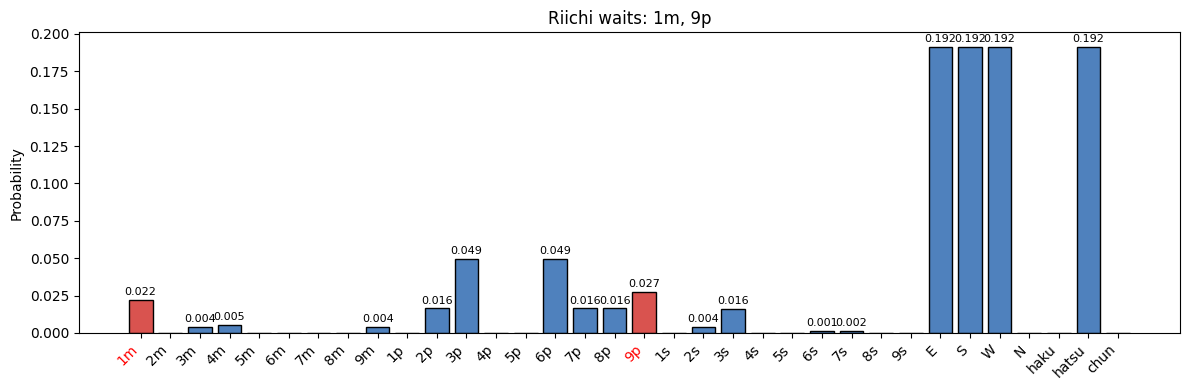

In [160]:
import random
from typing import Tuple, List, Optional, Iterable
import matplotlib.pyplot as plt

TILE_NAMES = (
    [f"{i+1}m" for i in range(9)] +
    [f"{i+1}p" for i in range(9)] +
    [f"{i+1}s" for i in range(9)] +
    ["E","S","W","N","haku","hatsu","chun"]
)


def random_riichi_hand34(
    shanten_calc: Shanten,
    used_tiles: Optional[List[int]] = None,
    max_tries: int = 20000,
    num_discards: int = 5
) -> Tuple[Tuple[int, ...], List[int]]:
    """
    Return (hand34_tuple, opponent_discards_136_list).
    - hand34_tuple: 34-count tuple representing a closed 13-tile hand in tenpai (shanten==0).
    - opponent_discards_136_list: list of tile136 ids (simulated discards) that do NOT make the riichi furiten.
    used_tiles: optional list of tile136 ids to exclude from the pool.
    """
    used_tiles = set(used_tiles or [])

    # visible counts from used_tiles (136->34)
    visible34 = [0]*34
    for t136 in used_tiles:
        visible34[t136 // 4] += 1

    # helper: is t34 a winning tile for hand34_counts
    def is_win_tile(hand34_counts, t34):
        tmp = list(hand34_counts)
        tmp[t34] += 1
        return shanten_calc.calculate_shanten(tmp) == -1

    # available 136 copies per tile34 given excluded set
    def avail_copies_from_excluded(excluded136):
        return [[c for c in (t34*4 + i for i in range(4)) if c not in excluded136] for t34 in range(34)]

    for _ in range(max_tries):
        # sample a 13-tile closed hand (respect 4-copy limit with visible)
        counts = [0]*34
        while sum(counts) < 13:
            t = random.randrange(34)
            if counts[t] + visible34[t] < 4:
                counts[t] += 1
        if shanten_calc.calculate_shanten(list(counts), use_chiitoitsu=random.sample((True,False),1)) != 0:
            continue

        # compute waits (tiles that complete the hand)
        waits = {t for t in range(34) if counts[t] < 4 and is_win_tile(counts, t)}
        if not waits:
            continue

        # forbidden tiles for furiten: wait itself and ±3 within same suit
        forbidden = set()
        for w in waits:
            forbidden.add(w)
            if 0 <= w < 27:
                base = w - (w % 9)
                for d in (-3, 3):
                    c = w + d
                    if base <= c < base + 9:
                        forbidden.add(c)

        # prepare available copies excluding used_tiles
        excluded136 = set(used_tiles)
        avail = avail_copies_from_excluded(excluded136)

        # candidate tile34s for discards (not forbidden and not exhausted)
        candidates = [t for t in range(34) if t not in forbidden and (visible34[t] < 4)]
        if not candidates:
            continue

        discards136: List[int] = []
        discard_counts34 = [0]*34

        # pick up to num_discards copies quickly (prefer lowest-index copy)
        for _ in range(num_discards):
            # refresh candidates that still have available copies
            candidates = [t for t in candidates if (visible34[t] + discard_counts34[t]) < 4 and any(c not in excluded136 for c in avail[t])]
            if not candidates:
                break
            t34 = random.choice(candidates)
            # pick first available 136 copy
            copy = next((c for c in avail[t34] if c not in excluded136), None)
            if copy is None:
                discard_counts34[t34] = 4 - visible34[t34]
                continue
            discards136.append(copy)
            excluded136.add(copy)
            discard_counts34[t34] += 1

        # final sanity: ensure none of the discards are forbidden
        if any((d // 4) in forbidden for d in discards136):
            continue

        return counts, discards136

    raise RuntimeError("Failed to generate a non-furiten riichi hand within max_tries")



def compute_remaining_counts(my_hand34: Tuple[int,...],
                             opponent_discards34: Tuple[int,...],
                             visible_calls34: Tuple[int,...] = None,
                             dead_wall34: Tuple[int,...] = None) -> List[int]:
    visible = [0]*34
    # my hand
    for i,c in enumerate(my_hand34):
        visible[i] += c
    # opponent discards
    for i,c in enumerate(opponent_discards34):
        visible[i] += c
    # calls (melds) if provided
    if visible_calls34:
        for i,c in enumerate(visible_calls34):
            visible[i] += c
    # dead wall if provided
    if dead_wall34:
        for i,c in enumerate(dead_wall34):
            visible[i] += c
    # remaining = 4 - visible (clamp >=0)
    remaining = [max(0, 4 - visible[i]) for i in range(34)]
    return remaining


def compute_tile_risk_for_riichi(
    my_hand34: Tuple[int,...],
    opponent_discards34: Tuple[int,...],
    opponent_pre_riichi_discards34: Optional[Tuple[int,...]] = None,
    params: Optional[dict] = None
) -> List[float]:
    """
    Compute per-tile risk for a riichi opponent, accounting for Furiten and Suji.
    - opponent_pre_riichi_discards34: 34-count tuple of discards made BEFORE riichi.
      If None, treat opponent_discards34 as pre-riichi (conservative).
    """
    if params is None:
        params = {}
    honor_boost = params.get("honor_boost", 1.6)
    pair_boost = params.get("pair_boost", 1.2)
    seq_boost = params.get("seq_boost", 1.1)
    min_suit_weight = params.get("min_suit_weight", 0.12)
    cap_risk = params.get("cap_risk", 0.95)
    suji_reduction = params.get("suji_reduction", 0.25)
    kabe_reduction = params.get("kabe_reduction", 0.08)

    # remaining counts
    total_remaining = max(1, sum(remaining))

    # suit discard counts and suit weights (same as before)
    suit_discards = [sum(opponent_discards34[s:s+9]) for s in (0,9,18)]
    suit_weight = [max(min_suit_weight, 1.0 - (sd / 6.0)) for sd in suit_discards]

    # pre-riichi discards (conservative default: all discards)
    pre = list(opponent_pre_riichi_discards34) if opponent_pre_riichi_discards34 is not None else list(opponent_discards34)

    # Furiten set: any tile34 that was discarded pre-riichi -> cannot be ron'd by that opponent
    furiten_set = {t for t, cnt in enumerate(pre) if cnt > 0}

    # Suji and kabe from pre-riichi discards only
    suji_safe = [False]*34
    kabe_safe = [False]*34
    for t in range(27):  # only suited tiles
        cnt = pre[t]
        if cnt <= 0:
            continue
        base = t - (t % 9)
        for delta in (-3, 3):
            nb = t + delta
            if base <= nb < base + 9:
                suji_safe[nb] = True
                if cnt >= 2:
                    kabe_safe[nb] = True

    # compute base risk and apply heuristics + furiten/suji
    risk = [0.0]*34
    for t in range(34):
        base = remaining[t] / total_remaining
        if 0 <= t < 27:
            suit = 0 if t < 9 else (1 if t < 18 else 2)
            w = suit_weight[suit]
        else:
            w = 1.0
        r = base * w

        # honors boost
        if 27 <= t <= 33 and opponent_discards34[t] == 0 and my_hand34[t] == 0:
            r *= honor_boost

        # pair/sequence boosts
        visible_copies = 4 - remaining[t]
        if visible_copies <= 1:
            r *= pair_boost
        if 0 <= t < 27:
            left = remaining[t-1] if t%9 != 0 else 0
            right = remaining[t+1] if t%9 != 8 else 0
            if left + right > 0:
                r *= seq_boost

        # Furiten: zero risk for any tile discarded pre-riichi
        if t in furiten_set:
            r = 0.0

        # Suji / kabe reductions (only suited tiles)
        if 0 <= t < 27:
            if kabe_safe[t]:
                r *= kabe_reduction
            elif suji_safe[t]:
                r *= suji_reduction

        r = min(r, cap_risk)
        risk[t] = r

    # normalize so max <= 1
    max_r = max(risk) if risk else 1.0
    if max_r > 0:
        risk = [min(1.0, x / max_r) for x in risk]

    return risk



def waits_from_tenpai(
    hand34: Iterable[int],
    shanten_calc,
    use_chiitoitsu: Optional[bool] = None
) -> List[int]:
    """
    Return a sorted list of tile34 indices that complete a tenpai (winning tiles).
    - hand34: 34-count iterable representing a closed 13-tile tenpai hand.
    - shanten_calc: object exposing calculate_shanten(list34, use_chiitoitsu=...) -> int.
    - use_chiitoitsu: if True/False forces chiitoitsu consideration; if None, let shanten_calc decide or randomize.
    """
    counts = list(hand34)
    if len(counts) != 34:
        raise ValueError("hand34 must be length 34 counts")
    waits = []
    for t in range(34):
        if counts[t] >= 4:
            continue
        tmp = counts[:] 
        tmp[t] += 1
        # call calculate_shanten with or without the chiitoitsu flag depending on signature
        try:
            s = shanten_calc.calculate_shanten(tmp, use_chiitoitsu=use_chiitoitsu) if use_chiitoitsu is not None else shanten_calc.calculate_shanten(tmp)
        except TypeError:
            s = shanten_calc.calculate_shanten(tmp)
        # many shanten implementations return -1 for a winning 14-tile hand
        if s == -1:
            waits.append(t)
    return sorted(waits)

def normalize_vector(v: List[float], mode: Optional[str]):
    if mode == "sum":
        s = sum(v)
        return [x / s if s > 0 else 0.0 for x in v]
    if mode == "max":
        m = max(v) if v else 1.0
        return [x / m if m > 0 else 0.0 for x in v]
    return list(v)

def tile_indices_from_34count(count34: Tuple[int,...]) -> List[int]:
    return [i for i,c in enumerate(count34) for _ in range(c)]

def plot_tile_risk(tile_risk: List[float],
                   opponent_waits34: Optional[Tuple[int,...]] = None,
                   normalize: Optional[str] = "sum",
                   figsize=(12,4)):
    """
    Plot 34-tile risk. If opponent_waits34 is provided (34-count iterable),
    the corresponding x-axis tile labels are colored red.
    - tile_risk: list[34] raw scores or probabilities
    - opponent_waits34: optional 34-count tuple/list marking waits (count>0 => wait)
    - normalize: "sum" to make sum==1, "max" to scale max==1, or None to leave raw
    """
    if len(tile_risk) != 34:
        raise ValueError("tile_risk must be length 34")

    vals = normalize_vector(tile_risk, normalize)
    x = list(range(34))
    labels = TILE_NAMES

    # determine wait indices (unique)
    waits = sorted({i for i,c in enumerate(opponent_waits34) if c>0} if opponent_waits34 else set())

    # bar colors: highlight waits in red, others in blue
    bar_colors = ["#d9534f" if i in waits else "#4f81bd" for i in x]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(x, vals, color=bar_colors, edgecolor="black")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    # color x-axis tick labels red for waits, black otherwise
    for i, lbl in enumerate(ax.get_xticklabels()):
        lbl.set_color("red" if i in waits else "black")

    ylabel = "Probability" if normalize == "sum" else "Relative risk"
    ax.set_ylabel(ylabel)

    # annotate values above bars (small font)
    maxv = max(vals) if vals else 0.0
    for b, v in zip(bars, vals):
        if v > 0:
            ax.text(b.get_x() + b.get_width()/2, v + maxv*0.01, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=8)

    # title: list waits as tile names
    wait_names = ", ".join(TILE_NAMES[i] for i in waits) if waits else "None"
    ax.set_title(f"Riichi waits: {wait_names}")
    fig.tight_layout()
    plt.show()


# MY
player, wall, dead_wall, draw_tile_136, dora_indicators_136 = setup_player("P")
player_hand_136 = player.hand.add(draw_tile_136)

# OPPONENT
riichi_hand_34, riichi_discards_136 = random_riichi_hand34(
    Shanten(),
    used_tiles=player_hand_136 + Hand136(dead_wall) + Hand136(dora_indicators_136), 
    num_discards=random.randint(1,25),
    max_tries = 40000
    )

wall_34 = Hand136(wall).to_34()
riichi_discards_34 = Hand136(riichi_discards_136).to_34()
riichi_hand_136 = Hand136(MahjongConverter().from_34_to_136(riichi_hand_34))
# remove the riichi_hand_34 and riichi_discard_136 from wall
for i in range(34):
    m = (riichi_discards_34[i] if riichi_discards_34[i]>0 else 0) + (riichi_hand_34[i] if riichi_hand_34[i]>0 else 0)
    wall_34[i] -= m

wall_34, wall_136 = wall_34.copy(), MahjongConverter.from_34_to_136(wall_34)

# VALIDATE: TOTAL=34*4=136
player_count = len(player_hand_136)                      # should be 14
riichi_count = sum(riichi_hand_34)                       # should be 13
wall_count = sum(wall_34)                                # remaining wall 136-ids
dead_wall_count = len(dead_wall)                         # dead wall 136-ids (usually 14)
dora_count = len(dora_indicators_136)                    # usually 1
riichi_discards_count = len(riichi_discards_136)         # what the riichi player discarded
# sanity total: sum of all groups that should equal 136
total = player_count + riichi_count + wall_count + dead_wall_count + dora_count + riichi_discards_count
# print in the requested compact format and show pass/fail
print(
    f"player_hand + riichi_hand + wall + dead_wall + dora_indicators + riichi_discards_count= "
    f"{player_count} + {riichi_count} + {wall_count} + {dead_wall_count} + {dora_count} + {riichi_discards_count} = {total}"
)
print("OK" if total == 136 else "MISSING TILE!" if total < 136 else "EXTRA TILE!")

print(f"MY HAND:{player_hand_136.to_mspzd()} --- OPPONENT HAND:{riichi_hand_136.to_mspzd()} | OPPONENT DISCARD:{Hand136(riichi_discards_136).to_mspzd()}")

remaining = compute_remaining_counts(player.hand.to_34(), opponent_discards34=riichi_discards_34)
tile_risk = compute_tile_risk_for_riichi(
    my_hand34=player.hand.to_34(), 
    opponent_discards34=riichi_discards_34,
    opponent_pre_riichi_discards34=None,
    )


riichi_waits = waits_from_tenpai(hand34=riichi_hand_34, shanten_calc=Shanten(), use_chiitoitsu=True)
plot_tile_risk(
    tile_risk=tile_risk, 
    opponent_waits34=[1 if i in riichi_waits else 0 for i in range(34)]
    )

# Same as above but 3 player in riichi

----- TILE COUNTS -----
hand,discard = [(13, 20), (13, 22), (13, 8)]
total per player = [33, 35, 21]
total opponent tiles = 89
Counts: player 14, riichi_hands 39, riichi_discards 50, wall 18, dora 1, dead wall 14
Total tiles: 136 (expected 136)
MUY BIEN: tile bookkeeping matches! :D
MY HAND: 7m5899p12355sHakuHatsuHatsuChunz


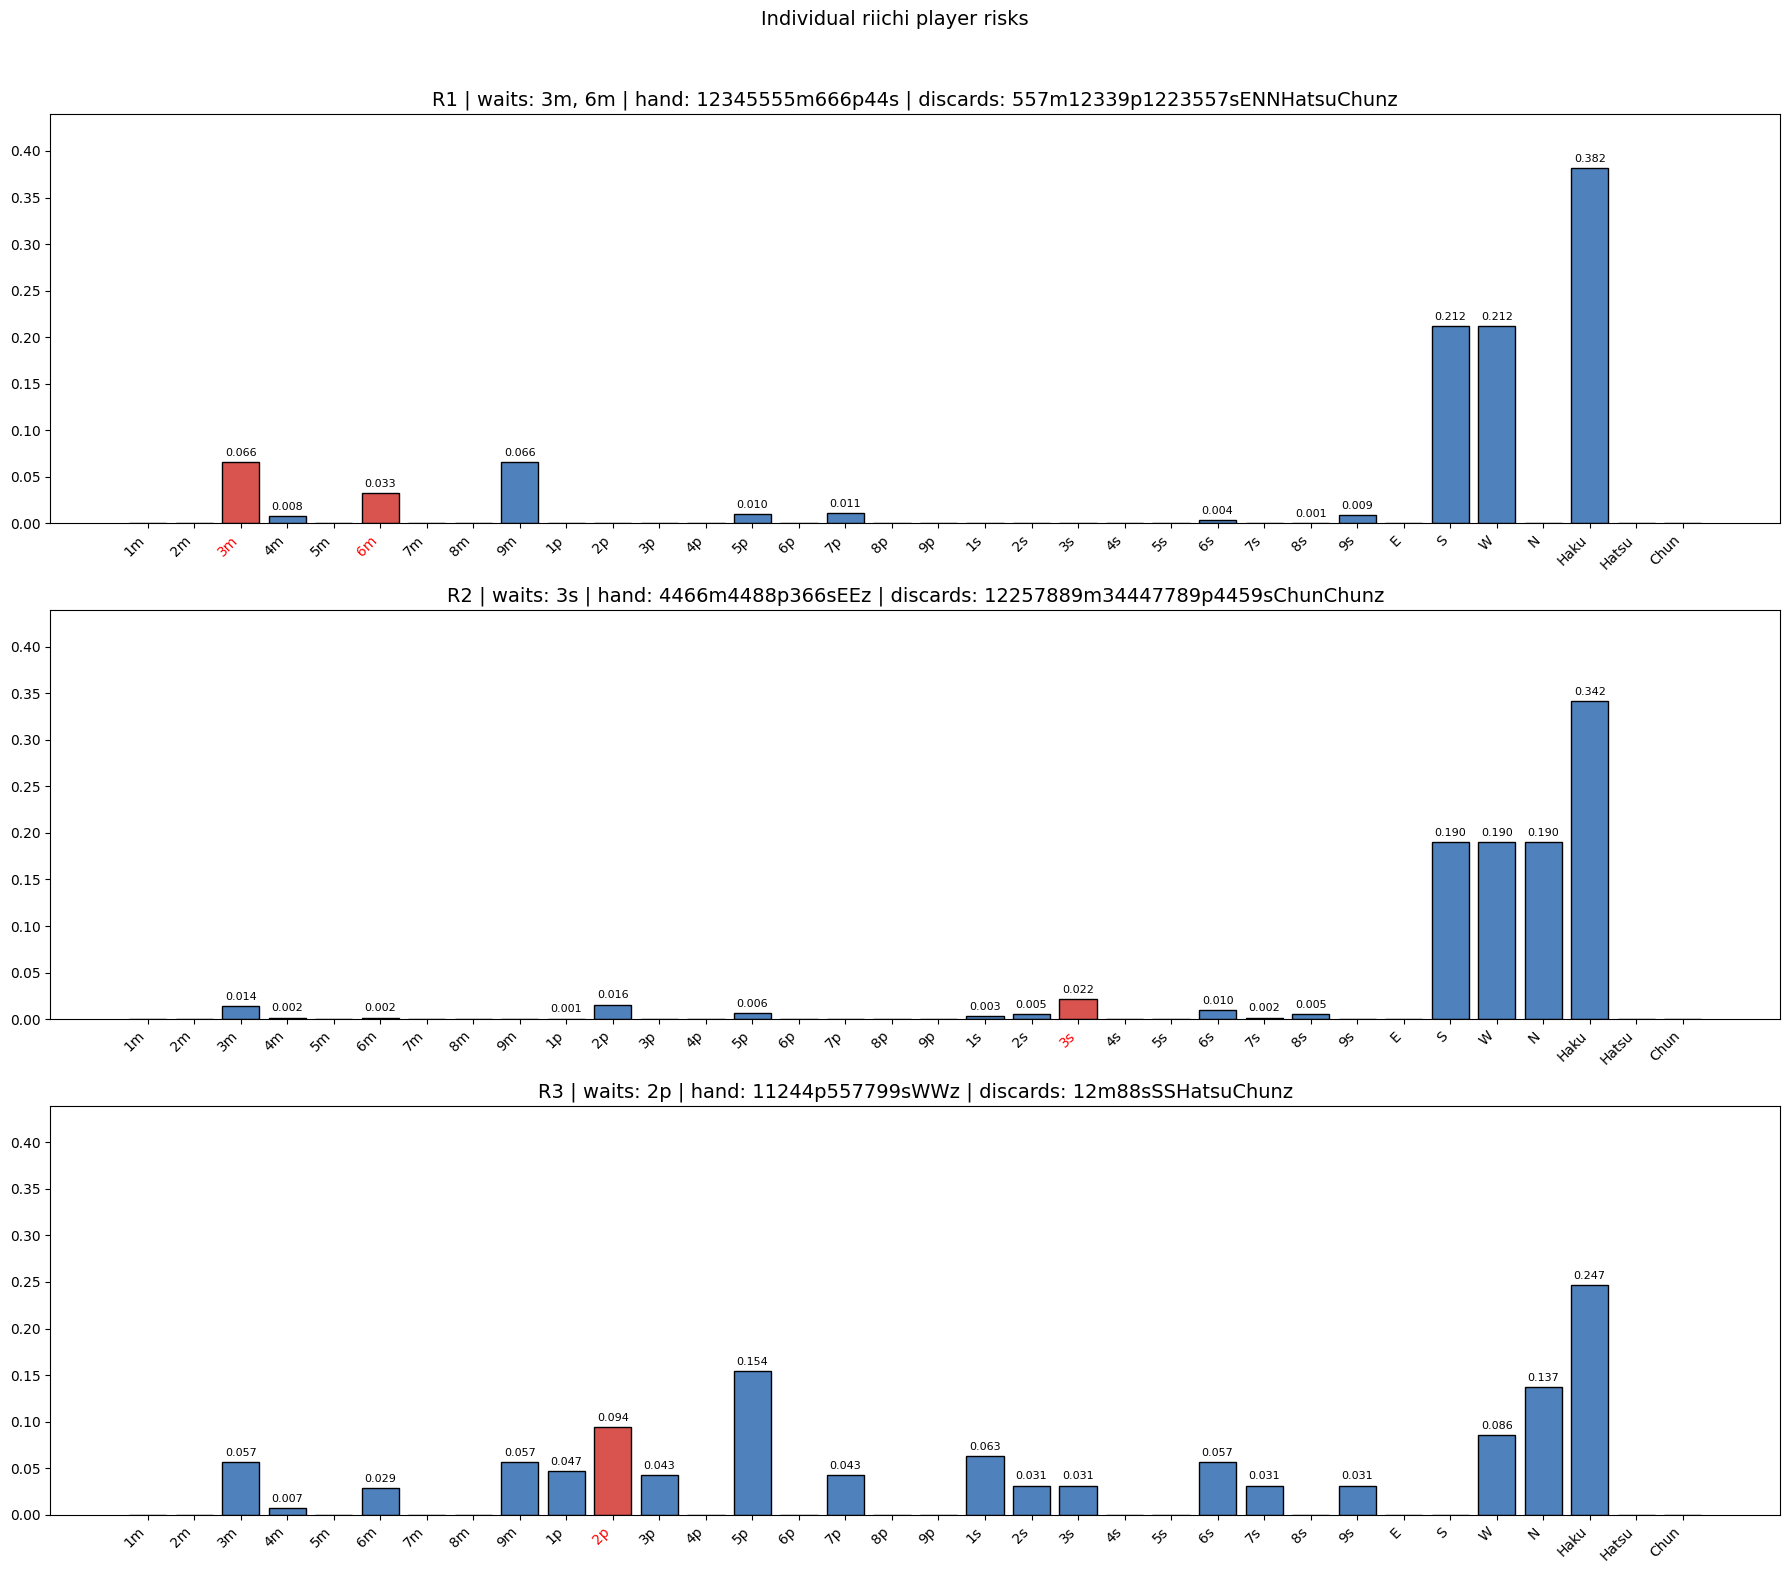

In [162]:
import random
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)

TILE_NAMES = ([f"{i+1}m" for i in range(9)] +
              [f"{i+1}p" for i in range(9)] +
              [f"{i+1}s" for i in range(9)] +
              ["E","S","W","N","Haku","Hatsu","Chun"])

def waits_from_tenpai(hand34):
    if sum(hand34)!=13: raise ValueError("hand must be 13 tiles")
    waits=[]
    for t in range(34):
        if hand34[t]>=4: continue
        tmp=list(hand34); tmp[t]+=1
        if is_agari_34(tmp): waits.append(t)
    return waits

def compute_tile_risk_for_riichi(my_hand34, opponent_discards34, wall_counts34, opponent_pre_riichi_discards34):
    params=dict(honor_boost=1.6,pair_boost=1.2,seq_boost=1.1,min_suit_weight=0.12,cap_risk=0.95,suji_reduction=0.25,kabe_reduction=0.08)
    remaining=list(wall_counts34); total=max(1,sum(remaining))
    suit_discards=[sum(opponent_discards34[s:s+9]) for s in (0,9,18)]
    suit_weight=[max(params['min_suit_weight'],1.0-(sd/6.0)) for sd in suit_discards]
    pre=list(opponent_pre_riichi_discards34)
    furiten={i for i,c in enumerate(pre) if c>0}
    suji=[False]*34; kabe=[False]*34
    for t in range(27):
        cnt=pre[t]
        if cnt<=0: continue
        base=t-(t%9)
        for d in (-3,3):
            nb=t+d
            if base<=nb<base+9:
                suji[nb]=True
                if cnt>=2: kabe[nb]=True
    raw=[0.0]*34
    for t in range(34):
        base=remaining[t]/total
        w = suit_weight[0] if t<9 else (suit_weight[1] if t<18 else (suit_weight[2] if t<27 else 1.0))
        r=base*w
        if 27<=t<=33 and opponent_discards34[t]==0 and my_hand34[t]==0: r*=params['honor_boost']
        visible=4-remaining[t]
        if visible<=1: r*=params['pair_boost']
        if 0<=t<27:
            left=remaining[t-1] if t%9!=0 else 0
            right=remaining[t+1] if t%9!=8 else 0
            if left+right>0: r*=params['seq_boost']
        if t in furiten: r=0.0
        if 0<=t<27:
            if kabe[t]: r*=params['kabe_reduction']
            elif suji[t]: r*=params['suji_reduction']
        raw[t]=min(r,params['cap_risk'])
    s=sum(raw)
    if s<=0:
        cand=[i for i in range(34) if raw[i]>0]
        if not cand: return [0.0]*34
        p=[0.0]*34
        for i in cand: p[i]=1.0/len(cand)
        return p
    return [x/s for x in raw]



# Simulation: deal player then 3 riichi opponents
# MY
player, wall, dead_wall_136, draw_tile_136, dora_indicators_136 = setup_player("P")
player_hand_136 = player.hand.add(draw_tile_136)
player_hand_34 = player_hand_136.to_34()
wall_34 = Hand136(wall).to_34()

# OPPONENT
riichi_opponents = [random_riichi_hand34( # riichi hand 34, discards 136
    Shanten(),
    used_tiles=player_hand_136 + Hand136(dead_wall_136) + Hand136(dora_indicators_136), 
    num_discards=random.randint(1,25),
    max_tries = 40000
    ) for _ in range(3)]

# TURN TO 34
riichi_opponents = [[a,Hand136(b).to_34()] for a,b in riichi_opponents] # both a,b in riichi_oppoenents[i] is 34

# remove the riichi_hand_34 and riichi_discard_136 from wall for all opponents
print("----- TILE COUNTS -----")
print(f"hand,discard = {[(sum(a),sum(b)) for a,b in riichi_opponents]}")
print(f"total per player = {[sum((sum(a),sum(b))) for a,b in riichi_opponents]}")
print(f"total opponent tiles = {sum([sum((sum(a),sum(b))) for a,b in riichi_opponents])}")
for i in range(34):
    for hand, disc in riichi_opponents:
        wall_34[i] -= hand[i] + disc[i]

player_count = sum(player_hand_34)
riichi_hands_count = sum(sum(hand34) for hand34, _ in riichi_opponents)
riichi_discards_count = sum(sum(disc34) for _, disc34 in riichi_opponents)
wall_count = sum(wall_34)
dora_count = len(dora_indicators_136)
dead_wall_count = len(dead_wall_136)
total = player_count + riichi_hands_count + riichi_discards_count + wall_count + dora_count + dead_wall_count
print(f"Counts: player {player_count}, riichi_hands {riichi_hands_count}, riichi_discards {riichi_discards_count}, wall {wall_count}, dora {dora_count}, dead wall {dead_wall_count}")
print("Total tiles:", total, "(expected 136)")
if total != 136:
    print("WARNING: tile bookkeeping mismatch! :[")
else:
    print("MUY BIEN: tile bookkeeping matches! :D")

# compute risks and plot
riichi_risks = [compute_tile_risk_for_riichi(hand, discard, wall_34, discard) for hand,discard in riichi_opponents]

# get waits
riichi_waits = [waits_from_tenpai(hand) for hand, _ in riichi_opponents]

# player hand in str format 
player_hand_str = [Hand136(MahjongConverter().from_34_to_136(hand)).to_mspzd() for hand,_ in riichi_opponents]

# player discards in str format
player_discard_str = [Hand136(MahjongConverter().from_34_to_136(discard)).to_mspzd() for _,discard in riichi_opponents]

# MY HANDS
print(f"{'='*50}\nMY HAND: {player_hand_136.to_mspzd()}")

fig, axes = plt.subplots(3, 1, figsize=(18, 16), sharey=True)
x = np.arange(34)
# compute a global top for consistent y-limits
global_max = max(max(r) for r in riichi_risks) if riichi_risks else 0.1
y_top = global_max * 1.15 if global_max > 0 else 0.1
for ax, (risk, waits, idx, hand_str, discards) in zip(axes, zip(riichi_risks, riichi_waits, range(3), player_hand_str, player_discard_str)):
    name = f"R{idx+1}"
    colors = ['#d9534f' if i in waits else '#4f81bd' for i in x]
    bars = ax.bar(x, risk, color=colors, edgecolor='black')
    # x ticks and labels
    ax.set_xticks(x)
    ax.set_xticklabels(TILE_NAMES, rotation=45, ha='right')
    # color tick labels red for waits
    for i, lbl in enumerate(ax.get_xticklabels()):
        lbl.set_color('red' if i in waits else 'black')
    # Title: player name (opponent), wait tiles, and your hand
    wait_names = ', '.join(TILE_NAMES[i] for i in waits) if waits else 'None'
    ax.set_title(f"{name} | waits: {wait_names} | hand: {hand_str} | discards: {discards}", fontsize=14)
    # y-limit
    ax.set_ylim(0, y_top)
    # annotate every bar with its numeric score value (formatted)
    # place the label slightly above the bar
    for i, b in enumerate(bars):
        v = risk[i]
        if v > 0:
            ax.text(b.get_x() + b.get_width() / 2,
                    v + y_top * 0.01,
                    f"{v:.3f}",
                    ha='center', va='bottom', fontsize=8, color='black')
    # also annotate wait bars with the player name (optional, redundant with title)
    maxv = max(risk) if risk else 0
    for i in waits:
        ax.text(i, risk[i] + maxv * 0.03, "", ha='center', va='bottom', fontsize=9, color='black')
plt.suptitle("Individual riichi player risks", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Score prediction
- Given any hand, predict the score of that hand

In [180]:
import random
from typing import Optional, List, Tuple, Iterable


def random_hand34(
    shanten_calc: Shanten,
    used_tiles: Optional[Iterable[int]] = None,
    max_tries: int = 20000,
    num_discards: int = 5,
    num_shanten: int = 0
) -> Tuple[Tuple[int, ...], List[int]]:
    """
    Return (hand34_tuple, opponent_discards_136_list).

    - shanten_calc: object exposing calculate_shanten(list34) -> int.
    - used_tiles: optional iterable of concrete 136-ids to exclude from the pool.
    - max_tries: how many random attempts to try before failing.
    - num_discards: number of concrete discards to generate (from remaining pool).
    - num_shanten: desired shanten value for the returned hand (e.g., 0 for tenpai).

    Behavior:
    - Samples random 13-tile closed hands (concrete 136 ids) from the remaining pool until
      a hand with calculate_shanten(hand34) == num_shanten is found (or raises RuntimeError).
    - Generates `num_discards` concrete 136-ids from the remaining pool (not overlapping the hand).
      If num_shanten == 0 (tenpai), discards are chosen so none of the discarded tile34 indices
      are winning tiles for the hand (i.e., they do not create furiten).
    - Returns a 34-count tuple for the hand and a list of concrete 136-ids for discards.
    """
    used_tiles = set(used_tiles or [])

    # build initial pool of concrete 136 ids excluding used_tiles
    full_pool = [i for i in range(136) if i not in used_tiles]
    if len(full_pool) < 13:
        raise ValueError("Not enough tiles in pool after excluding used_tiles")

    def calc_shanten_from_136_list(concrete13):
        hand34 = Hand136(concrete13).to_34()
        try:
            return shanten_calc.calculate_shanten(list(hand34))
        except TypeError:
            return shanten_calc.calculate_shanten(hand34)

    def is_win_tile_from_hand34(hand34_counts, t34):
        tmp = list(hand34_counts)
        tmp[t34] += 1
        try:
            return shanten_calc.calculate_shanten(tmp) == -1
        except TypeError:
            return shanten_calc.calculate_shanten(tuple(tmp)) == -1

    tries = 0
    while tries < max_tries:
        tries += 1
        # sample 13 concrete tiles from pool
        if len(full_pool) < 13:
            raise RuntimeError("Not enough tiles left in pool to sample a hand")
        candidate = random.sample(full_pool, 13)
        sh = calc_shanten_from_136_list(candidate)
        if sh != num_shanten:
            # put back implicitly by not removing from full_pool (we sampled without removal)
            continue

        # candidate hand meets shanten requirement
        hand34 = Hand136(candidate).to_34()

        # build a working pool for discards: concrete ids not in candidate and not in used_tiles
        remaining_pool = [t for t in full_pool if t not in candidate]

        # If tenpai, compute winning tiles (waits) in 34-space
        waits34 = set()
        if num_shanten == 0:
            for t34 in range(34):
                if is_win_tile_from_hand34(hand34, t34):
                    waits34.add(t34)

        # choose discards
        discards = []
        if num_shanten == 0:
            # choose discards that do NOT make the hand furiten:
            # i.e., discard tile's tile34 must NOT be in waits34
            # sample from remaining_pool but filter out any concrete tile whose tile34 is in waits34
            safe_pool = [t for t in remaining_pool if (t // 4) not in waits34]
            # if not enough safe tiles, fall back to remaining_pool but try to minimize furiten risk
            if len(safe_pool) >= num_discards:
                discards = random.sample(safe_pool, num_discards)
            else:
                # best-effort: take all safe tiles, then fill with tiles whose tile34 is least likely to be a wait
                discards = safe_pool.copy()
                need = num_discards - len(discards)
                # compute counts of remaining tile34 to prefer discarding tiles with many visible copies (less risky)
                # sort remaining_pool by remaining copies of that tile34 (descending) to prefer discarding abundant tiles
                tile34_counts = {}
                for t in remaining_pool:
                    tile34_counts.setdefault(t // 4, 0)
                    tile34_counts[t // 4] += 1
                candidates = [t for t in remaining_pool if (t // 4) not in waits34]
                # if still not enough, include tiles in waits but prefer those with many visible copies
                if len(candidates) < need:
                    # include all remaining_pool but sort by tile34_counts descending
                    remaining_sorted = sorted(remaining_pool, key=lambda x: tile34_counts.get(x // 4, 0), reverse=True)
                    for t in remaining_sorted:
                        if t in discards: continue
                        discards.append(t)
                        if len(discards) >= num_discards:
                            break
                else:
                    discards.extend(random.sample(candidates, need))
        else:
            # not tenpai: random discards from remaining_pool
            if len(remaining_pool) < num_discards:
                discards = remaining_pool.copy()
            else:
                discards = random.sample(remaining_pool, num_discards)

        # final sanity: ensure discards do not overlap hand
        if any(d in candidate for d in discards):
            # improbable because we sampled from remaining_pool, but guard anyway
            continue

        # success: return hand34 tuple and discards list
        return hand34, discards

    raise RuntimeError(f"Failed to generate a hand with shanten={num_shanten} after {max_tries} tries")


num_shanten = 1
hand_34, discard_136 = random_hand34(
    shanten_calc = Shanten(),
    used_tiles = None,
    max_tries = 40000,
    num_discards = random.randint(1,25),
    num_shanten = num_shanten
)
hand_136 = Hand136(MahjongConverter().from_34_to_136(hand_34))
shanten_check = Shanten().calculate_shanten(hand_34)
print(f"param shanten = {num_shanten} <-> check shanten = {shanten_check}")



13
param shanten = 1 <-> check shanten = 1
